# XGBoost baseline

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
    
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

src_path = str(Path("../src").resolve())
if src_path not in sys.path:
    sys.path.insert(0, src_path)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (10, 4)

PROC_DIR = Path("../data/processed")
assert PROC_DIR.exists(), f"{PROC_DIR.resolve()} not found"

## 1. Load processed splits

In [2]:
train = pd.read_parquet(PROC_DIR / "train.parquet")
val   = pd.read_parquet(PROC_DIR / "val.parquet")
test  = pd.read_parquet(PROC_DIR / "test.parquet") 

print(f"train shape      : {train.shape}")
print(f"val   shape      : {val.shape}")
print(f"test  shape      : {test.shape}") 

print("-" * 30)

print(f"train fraud rate : {train['isFraud'].mean():.4%}")
print(f"val   fraud rate : {val['isFraud'].mean():.4%}")
print(f"test  fraud rate : {test['isFraud'].mean():.4%}") 

train shape      : (413378, 81)
val   shape      : (88581, 81)
test  shape      : (88581, 81)
------------------------------
train fraud rate : 3.5169%
val   fraud rate : 3.4341%
test  fraud rate : 3.4804%


## 2. Feature / target split

In [3]:
DROP_COLS = ["TransactionID", "TransactionDT", "uid"]
TARGET = "isFraud"

drop_now = DROP_COLS
feature_cols = [c for c in train.columns if c not in drop_now + [TARGET]]

X_train, y_train = train[feature_cols], train[TARGET]
X_val,   y_val   = val[feature_cols],   val[TARGET]
X_test,  y_test  = test[feature_cols],  test[TARGET] 

print(f"n features   : {len(feature_cols)}")
print(f"X_train      : {X_train.shape}")
print(f"X_val        : {X_val.shape}")
print(f"X_test       : {X_test.shape}") 

n features   : 79
X_train      : (413378, 79)
X_val        : (88581, 79)
X_test       : (88581, 79)


## 3. Train XGBoost

In [25]:
# Rationale: Penalize complexity and force generalization
params = dict(
    n_estimators=2000,
    tree_method="hist",
    scale_pos_weight=1,             # Set to 1 for PR-AUC stability
    learning_rate=0.02,             # Slightly lower for smoother convergence
    max_depth=4,                    # Aggressive pruning to prevent memorization
    subsample=0.7,                  # Increased stochasticity
    colsample_bytree=0.6,           # Fewer features per tree to reduce correlation
    min_child_weight=100,           # High value to fight the 0.36 gap
    reg_alpha=2.0,                  # Stronger L1 to zero out noisy features
    reg_lambda=5.0,                 # Stronger L2 to prevent extreme weights
    gamma=0.5,                      # Higher threshold for any split to happen
    eval_metric="aucpr",
    early_stopping_rounds=50,       # Tighter stopping to prevent tail-end overfitting
    random_state=42,
    n_jobs=-1,
)

model = xgb.XGBClassifier(**params)
model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50,
)

print(f"best iteration : {model.best_iteration}")
print(f"best PR-AUC    : {model.best_score:.4f}")

[0]	validation_0-aucpr:0.23453	validation_1-aucpr:0.23283
[50]	validation_0-aucpr:0.41268	validation_1-aucpr:0.38317
[100]	validation_0-aucpr:0.44093	validation_1-aucpr:0.39556
[150]	validation_0-aucpr:0.45896	validation_1-aucpr:0.40456
[200]	validation_0-aucpr:0.47319	validation_1-aucpr:0.41361
[250]	validation_0-aucpr:0.48389	validation_1-aucpr:0.42127
[300]	validation_0-aucpr:0.49301	validation_1-aucpr:0.42606
[350]	validation_0-aucpr:0.50073	validation_1-aucpr:0.43011
[400]	validation_0-aucpr:0.50776	validation_1-aucpr:0.43368
[450]	validation_0-aucpr:0.51373	validation_1-aucpr:0.43620
[500]	validation_0-aucpr:0.51892	validation_1-aucpr:0.43822
[550]	validation_0-aucpr:0.52405	validation_1-aucpr:0.44005
[600]	validation_0-aucpr:0.52875	validation_1-aucpr:0.44148
[650]	validation_0-aucpr:0.53324	validation_1-aucpr:0.44357
[700]	validation_0-aucpr:0.53750	validation_1-aucpr:0.44479
[750]	validation_0-aucpr:0.54144	validation_1-aucpr:0.44675
[800]	validation_0-aucpr:0.54525	validation

## 4. Metrics — PR-AUC, ROC-AUC, KS

In [26]:
y_val_proba = model.predict_proba(X_val)[:, 1]

pr_auc  = average_precision_score(y_val, y_val_proba)
roc_auc = roc_auc_score(y_val, y_val_proba)

fpr, tpr, _ = roc_curve(y_val, y_val_proba)
ks = float(np.max(tpr - fpr))

print(f"PR-AUC  (val) : {pr_auc:.4f}")
print(f"ROC-AUC (val) : {roc_auc:.4f}")
print(f"KS      (val) : {ks:.4f}")

PR-AUC  (val) : 0.4713
ROC-AUC (val) : 0.8757
KS      (val) : 0.5964


## 5. Feature importance

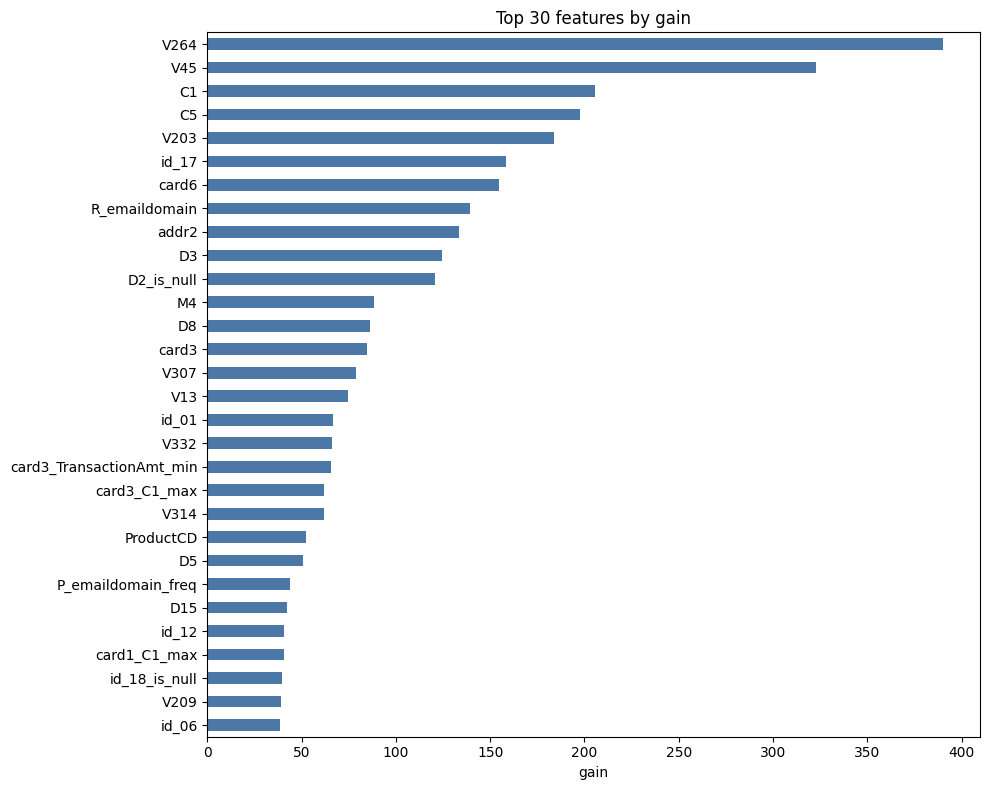

In [27]:
booster = model.get_booster()
importance_dict = booster.get_score(importance_type="gain")

importance = (
    pd.Series(importance_dict, name="gain")
    .sort_values(ascending=False)
    .head(30)
)

fig, ax = plt.subplots(figsize=(10, 8))
importance[::-1].plot(kind="barh", ax=ax, color="#4c78a8")
ax.set_title("Top 30 features by gain")
ax.set_xlabel("gain")
plt.tight_layout()
plt.show()

In [28]:
all_importances = pd.Series(booster.get_score(importance_type="gain"))

zero_importance_features = [f for f in feature_cols if f not in all_importances.index]

bottom_30_importance = all_importances.sort_values(ascending=True).head(30)

print(f"--- Feature Importance Analysis ---")
print(f"Total features evaluated: {len(feature_cols)}")
print(f"Zero importance features detected: {len(zero_importance_features)}")
print(f"Lowest 20 features by gain:\n{bottom_30_importance.head(20)}")

--- Feature Importance Analysis ---
Total features evaluated: 79
Zero importance features detected: 0
Lowest 20 features by gain:
id_11                        8.868519
id_04                       10.418165
dt_day_week                 10.607388
id_19                       13.049842
D4_is_null                  13.659847
D9                          14.117490
uid_D1_nunique              14.573549
card4                       14.582253
uid_C1_max                  15.133546
is_weekend                  15.477531
amt_zscore_uid              15.512681
uid_dist1_mean              15.568524
uid_TransactionAmt_min      16.012796
dist1                       16.221437
uid_TransactionAmt_std      17.236084
V271                        17.515347
card1_TransactionAmt_min    17.682140
dist2_is_null               17.695856
uid_C1_mean                 17.875154
addr1_TransactionAmt_min    18.169321
dtype: float64


## 6. PR curve and ROC curve

Both curves are computed on the validation set with the full predicted-probability vector.

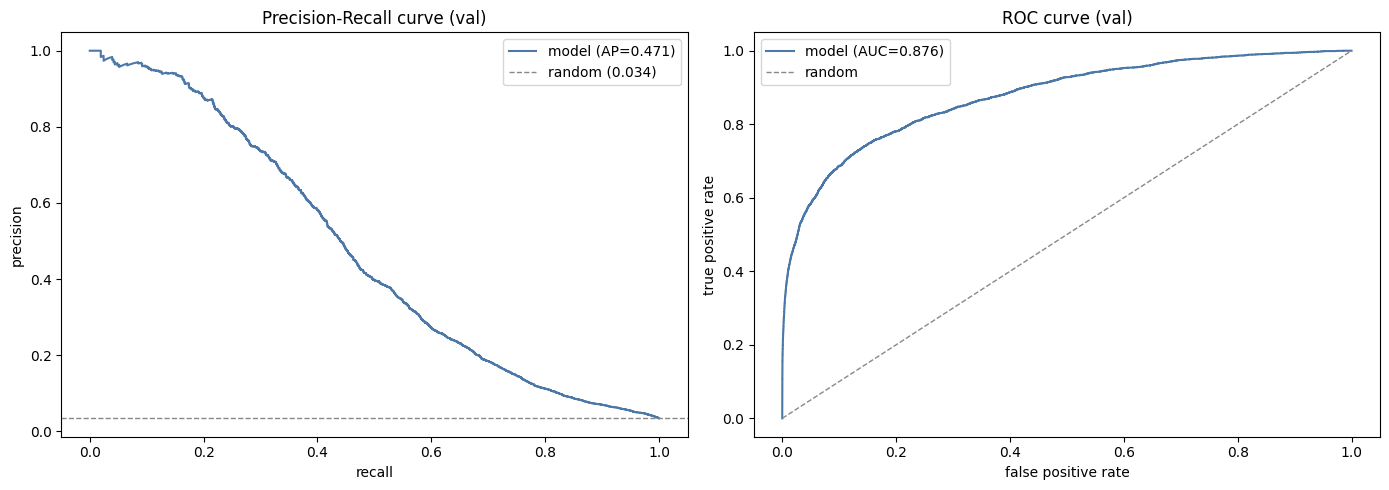

In [29]:
precision, recall, _ = precision_recall_curve(y_val, y_val_proba)
baseline_pr = float(y_val.mean())  # PR baseline = positive rate

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recall, precision, color="#4c78a8", label=f"model (AP={pr_auc:.3f})")
axes[0].axhline(baseline_pr, color="#888", linestyle="--", linewidth=1,
                label=f"random ({baseline_pr:.3f})")
axes[0].set_xlabel("recall")
axes[0].set_ylabel("precision")
axes[0].set_title("Precision-Recall curve (val)")
axes[0].legend()

axes[1].plot(fpr, tpr, color="#4c78a8", label=f"model (AUC={roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="#888", linestyle="--", linewidth=1, label="random")
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC curve (val)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Baseline XGBoost Test

--- Final Test Set Results ---
PR-AUC  (test) : 0.4419 (Val was: 0.5019)
ROC-AUC (test) : 0.8703 (Val was: 0.8917)
KS      (test) : 0.5727 (Val was: 0.6153)


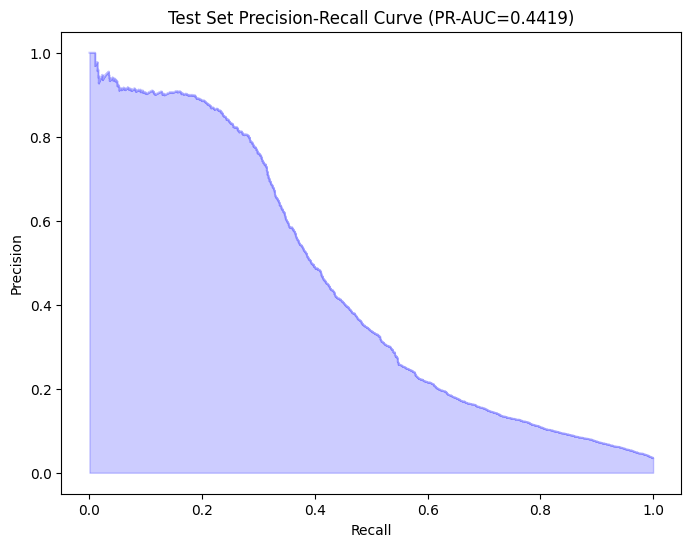

In [30]:
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Prediction on Test Set
y_test_proba = model.predict_proba(X_test)[:, 1]

# Metric Calculation
test_pr_auc  = average_precision_score(y_test, y_test_proba)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

# KS Statistic Calculation
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
test_ks = float(np.max(tpr - fpr))

# Print Results
print(f"--- Final Test Set Results ---")
print(f"PR-AUC  (test) : {test_pr_auc:.4f} (Val was: 0.5019)")
print(f"ROC-AUC (test) : {test_roc_auc:.4f} (Val was: 0.8917)")
print(f"KS      (test) : {test_ks:.4f} (Val was: 0.6153)")

# Precision-Recall Curve Comparison
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='b', alpha=0.2, where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Test Set Precision-Recall Curve (PR-AUC={test_pr_auc:.4f})')
plt.show()

## 7. Optuna

In [5]:
import optuna
import xgboost as xgb
from sklearn.metrics import average_precision_score

In [6]:
def objective(trial):
    params = dict(
        n_estimators=2000,
        tree_method="hist",
        scale_pos_weight=1,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.05, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 6),
        subsample=trial.suggest_float("subsample", 0.6, 0.8),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 0.7),
        min_child_weight=trial.suggest_int("min_child_weight", 30, 200, step=10),
        reg_alpha=trial.suggest_float("reg_alpha", 0.5, 5.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 10.0, log=True),
        gamma=trial.suggest_float("gamma", 0.1, 1.0),
        eval_metric="aucpr",
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=6,
    )

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=0,
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    val_prauc = average_precision_score(y_val, val_pred)

    train_pred = model.predict_proba(X_train)[:, 1]
    train_prauc = average_precision_score(y_train, train_pred)

    gap = train_prauc - val_prauc

    if gap > 0.15:
        print(f"Trial {trial.number}: gap={gap:.4f}, pruning")
        raise optuna.TrialPruned()

    trial.set_user_attr("train_prauc", round(train_prauc, 4))
    trial.set_user_attr("val_prauc", round(val_prauc, 4))
    trial.set_user_attr("gap", round(gap, 4))
    trial.set_user_attr("best_iteration", model.best_iteration)

    return val_prauc


study = optuna.create_study(
    direction="maximize",
    study_name="fraudlens_xgb_v1",
    sampler=optuna.samplers.TPESampler(seed=42),
)

study.optimize(
    objective,
    n_trials=20,
    n_jobs=2,                  
    show_progress_bar=True,
)

[I 2026-04-23 06:19:50,414] A new study created in memory with name: fraudlens_xgb_v1


  0%|          | 0/20 [00:00<?, ?it/s]

Trial 1: gap=0.1909, pruning
[I 2026-04-23 06:23:51,763] Trial 1 pruned. 
Trial 0: gap=0.1515, pruning
[I 2026-04-23 06:25:07,297] Trial 0 pruned. 
[I 2026-04-23 06:28:40,971] Trial 2 finished with value: 0.4738745354695161 and parameters: {'learning_rate': 0.015064018954969822, 'max_depth': 5, 'subsample': 0.6006582368104585, 'colsample_bytree': 0.680133209337717, 'min_child_weight': 130, 'reg_alpha': 2.1061464015062277, 'reg_lambda': 3.1604762511937814, 'gamma': 0.8585714387949682}. Best is trial 2 with value: 0.4738745354695161.
[I 2026-04-23 06:30:43,962] Trial 3 finished with value: 0.4740272535620063 and parameters: {'learning_rate': 0.011215156860912498, 'max_depth': 6, 'subsample': 0.7289841485258678, 'colsample_bytree': 0.6890205586387426, 'min_child_weight': 130, 'reg_alpha': 3.5433034723695433, 'reg_lambda': 8.666093755059142, 'gamma': 0.9573027806916462}. Best is trial 3 with value: 0.4740272535620063.
[I 2026-04-23 06:34:12,040] Trial 4 finished with value: 0.4538673748675

In [8]:
import os
print(f"CPU cores available: {os.cpu_count()}")

CPU cores available: 16


In [7]:
best = study.best_trial
print(f"Best val PR-AUC : {best.value:.4f}")
print(f"Train PR-AUC    : {best.user_attrs['train_prauc']}")
print(f"Gap             : {best.user_attrs['gap']}")
print(f"Best iteration  : {best.user_attrs['best_iteration']}")
print(f"\nBest params:")
for k, v in best.params.items():
    print(f"  {k}: {round(v, 6) if isinstance(v, float) else v}")

Best val PR-AUC : 0.4841
Train PR-AUC    : 0.6339
Gap             : 0.1498
Best iteration  : 1999

Best params:
  learning_rate: 0.018902
  max_depth: 6
  subsample: 0.71467
  colsample_bytree: 0.575002
  min_child_weight: 160
  reg_alpha: 3.518176
  reg_lambda: 2.141525
  gamma: 0.666359


In [8]:
final_params = dict(
    n_estimators=2000,
    tree_method="hist",
    scale_pos_weight=1,
    eval_metric="aucpr",
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    **best.params,
)

final_model = xgb.XGBClassifier(**final_params)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50,
)

print(f"\nFinal best iteration: {final_model.best_iteration}")
print(f"Final best PR-AUC  : {final_model.best_score:.4f}")

[0]	validation_0-aucpr:0.22414	validation_1-aucpr:0.22308
[50]	validation_0-aucpr:0.41562	validation_1-aucpr:0.39176
[100]	validation_0-aucpr:0.44932	validation_1-aucpr:0.40282
[150]	validation_0-aucpr:0.47108	validation_1-aucpr:0.41426
[200]	validation_0-aucpr:0.48701	validation_1-aucpr:0.42309
[250]	validation_0-aucpr:0.49913	validation_1-aucpr:0.43076
[300]	validation_0-aucpr:0.50902	validation_1-aucpr:0.43608
[350]	validation_0-aucpr:0.51837	validation_1-aucpr:0.44054
[400]	validation_0-aucpr:0.52607	validation_1-aucpr:0.44485
[450]	validation_0-aucpr:0.53316	validation_1-aucpr:0.44811
[500]	validation_0-aucpr:0.53944	validation_1-aucpr:0.45024
[550]	validation_0-aucpr:0.54518	validation_1-aucpr:0.45322
[600]	validation_0-aucpr:0.55016	validation_1-aucpr:0.45554
[650]	validation_0-aucpr:0.55528	validation_1-aucpr:0.45757
[700]	validation_0-aucpr:0.55996	validation_1-aucpr:0.45966
[750]	validation_0-aucpr:0.56395	validation_1-aucpr:0.46139
[800]	validation_0-aucpr:0.56781	validation

In [10]:
import numpy as np
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve

def ks_stat(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return float(np.max(tpr - fpr))

def precision_top1pct(y_true, y_prob):
    n = max(1, int(len(y_true) * 0.01))
    top_idx = np.argsort(y_prob)[::-1][:n]
    return float(np.mean(y_true.iloc[top_idx] if hasattr(y_true, 'iloc') else y_true[top_idx]))

def recall_at_1pct_fpr(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    mask = fpr <= 0.01
    return float(np.max(tpr[mask])) if mask.any() else 0.0

for name, X, y in [("train", X_train, y_train),
                    ("val",   X_val,   y_val),
                    ("test",  X_test,  y_test)]:
    pred = final_model.predict_proba(X)[:, 1]
    pr   = average_precision_score(y, pred)
    roc  = roc_auc_score(y, pred)
    ks   = ks_stat(y, pred)
    p1   = precision_top1pct(y, pred)
    r1   = recall_at_1pct_fpr(y, pred)
    print(f"{name:5s}  PR-AUC: {pr:.4f}  ROC-AUC: {roc:.4f}  KS: {ks:.4f}  P@top1%: {p1:.4f}  R@1%FPR: {r1:.4f}")

train  PR-AUC: 0.6331  ROC-AUC: 0.9201  KS: 0.6864  P@top1%: 0.9511  R@1%FPR: 0.5590
val    PR-AUC: 0.4834  ROC-AUC: 0.8790  KS: 0.5984  P@top1%: 0.8328  R@1%FPR: 0.4139
test   PR-AUC: 0.4491  ROC-AUC: 0.8727  KS: 0.5736  P@top1%: 0.8531  R@1%FPR: 0.3678


In [11]:
import joblib
from pathlib import Path

PROC_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(final_model, PROC_DIR / "xgb_tuned_v1.joblib")
print(f"\nModel saved → {PROC_DIR / 'xgb_tuned_v1.joblib'}")


Model saved → ..\data\processed\xgb_tuned_v1.joblib
